<a href="https://colab.research.google.com/github/sk27110/DL2/blob/HW3/HW3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/xmed-lab/TAM.git

Cloning into 'TAM'...
remote: Enumerating objects: 41, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 41 (delta 11), reused 34 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (41/41), 4.53 MiB | 47.38 MiB/s, done.
Resolving deltas: 100% (11/11), done.


In [ ]:
%cd /content/TAM

/content/TAM


In [ ]:
!pip install -q "transformers>=4.52.1" accelerate qwen-vl-utils datasets pillow matplotlib scipy numpy nltk pymupdf fitz rouge_score
!pip install -q bitsandbytes


!apt-get update -qq
!apt-get install -y -qq texlive-xetex texlive-fonts-recommended texlive-latex-recommended

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 77.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 118.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.7/110.7 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.9/425.9 kB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 133.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.4 MB/s eta 0:00:00
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Extracting templates from packages: 100%
Preconfiguring 

In [ ]:
!pip uninstall -y fitz
!pip uninstall -y PyMuPDF
!pip install -q PyMuPDF

Found existing installation: fitz 0.0.1.dev2
Uninstalling fitz-0.0.1.dev2:
  Successfully uninstalled fitz-0.0.1.dev2
Found existing installation: PyMuPDF 1.27.2.3
Uninstalling PyMuPDF-1.27.2.3:
  Successfully uninstalled PyMuPDF-1.27.2.3


In [ ]:
import os
import json
import math
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from IPython.display import display, Image as IPyImage

from transformers import AutoProcessor


try:
    from transformers import Qwen2_5_VLForConditionalGeneration
except Exception:
    Qwen2_5_VLForConditionalGeneration = None


try:
    from transformers import AutoModelForImageTextToText
except Exception:
    AutoModelForImageTextToText = None

from qwen_vl_utils import process_vision_info
from tam import TAM

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())


torch: 2.11.0+cu128
cuda available: True


Создадим ручками датасет на 5 примеров, картинки возьмем из интернета

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

DATA_DIR = "/content/tam_data_v2/images"

mini_dataset = [
    {
        "id": "zebras",
        "image_path": os.path.join(DATA_DIR, "/content/tam_data_v2/images/Equus_quagga.jpg"),
        "prompt": "What animals are visible in the image? Describe their location.",
        "target_words": ["zebra", "zebras", "animal"]
    },
    {
        "id": "dog",
        "image_path": os.path.join(DATA_DIR, "/content/tam_data_v2/images/517676504.800x600w.jpg"),
        "prompt": "Describe the animal in the image and what it is doing.",
        "target_words": ["dog", "animal"]
    },
    {
        "id": "food",
        "image_path": os.path.join(DATA_DIR, "/content/tam_data_v2/images/images.jpeg"),
        "prompt": "Describe the food items in the image.",
        "target_words": ["food", "pizza", "plate"]
    },
    {
        "id": "airplane",
        "image_path": os.path.join(DATA_DIR, "/content/tam_data_v2/images/66a78e3782682c6ff05a5ab4.jpg"),
        "prompt": "What vehicle is shown in the image? Describe it briefly.",
        "target_words": ["airplane", "plane", "aircraft"]
    },
    {
        "id": "tennis",
        "image_path": os.path.join(DATA_DIR, "/content/tam_data_v2/images/347803953499035.jpeg"),
        "prompt": "Describe the person and the sports equipment in the image.",
        "target_words": ["person", "tennis", "racket", "racquet"]
    },
]


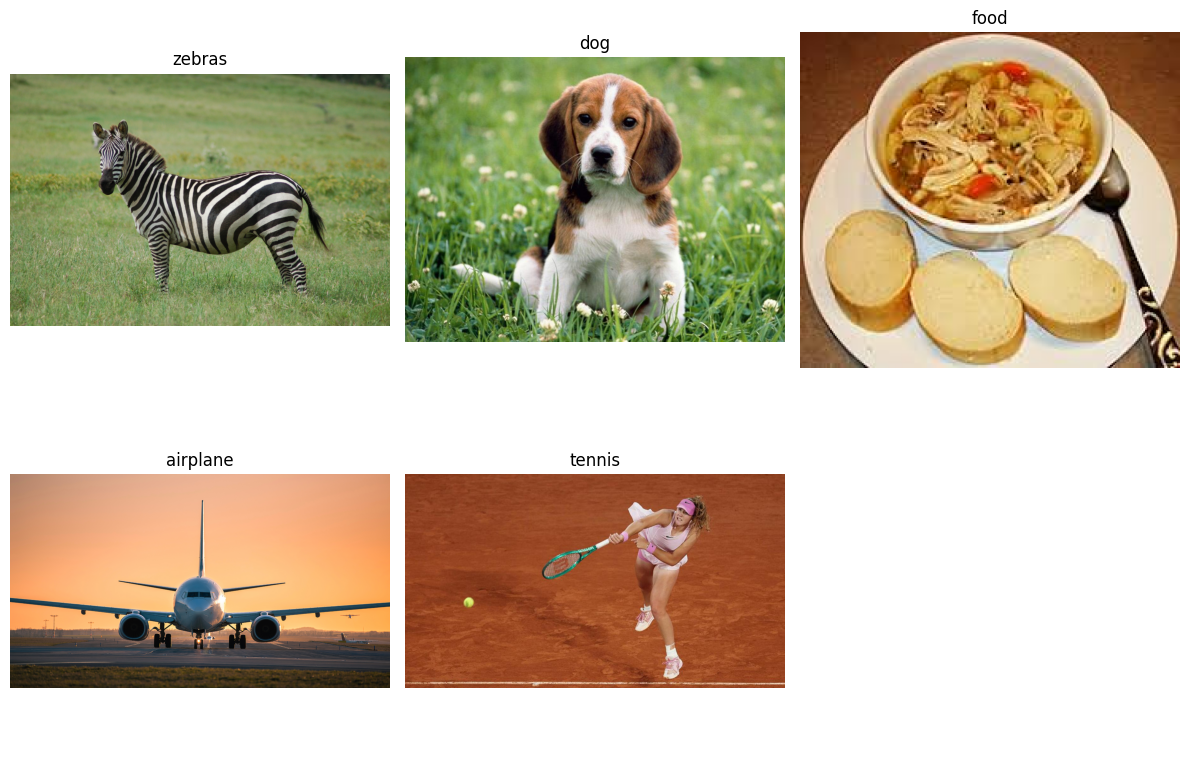

In [ ]:

n = len(mini_dataset)
cols = min(3, n)
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))

if n == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for ax, item in zip(axes, mini_dataset):
    img = Image.open(item["image_path"]).convert("RGB")
    ax.imshow(img)
    ax.set_title(item["id"])
    ax.axis("off")

for ax in axes[len(mini_dataset):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
from huggingface_hub import login

login(token="секрет")


В качестве VLM возьмем Qwen 2.5 (в статье была кажется Qwen2)

In [ ]:
model_name = "Qwen/Qwen2.5-VL-3B-Instruct"

processor = AutoProcessor.from_pretrained(model_name, trust_remote_code=True)

if Qwen2_5_VLForConditionalGeneration is not None:
    model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
        model_name,
        torch_dtype=torch.float16,
        device_map="auto",
        trust_remote_code=True,
    )
else:
    model = AutoModelForImageTextToText.from_pretrained(
        model_name,
        torch_dtype=torch.float16,
        device_map="auto",
        trust_remote_code=True,
    )

model.eval()
print("Loaded:", model_name)
print("Device:", next(model.parameters()).device)


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

Loaded: Qwen/Qwen2.5-VL-3B-Instruct
Device: cuda:0


In [ ]:
def decode_token_ids(token_ids, max_items=200):
    rows = []
    for i, tid in enumerate(token_ids[:max_items]):
        try:
            tok = processor.tokenizer.decode([tid])
        except Exception:
            tok = str(tid)
        rows.append((i, tid, repr(tok)))
    return pd.DataFrame(rows, columns=["pos", "token_id", "decoded"])


@torch.inference_mode()
def generate_with_qwen25_vl(image_path, prompt, max_new_tokens=64):
    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": image_path,
                    "min_pixels": 224 * 224,
                    "max_pixels": 448 * 448,
                },
                {"type": "text", "text": prompt},
            ],
        }
    ]

    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True,
    )

    image_inputs, video_inputs = process_vision_info(messages)

    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    ).to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        use_cache=True,
        output_hidden_states=True,
        return_dict_in_generate=True,
    )

    generated_ids = outputs.sequences

    input_len = inputs["input_ids"].shape[1]
    answer_ids = generated_ids[0, input_len:]
    answer_text = processor.decode(answer_ids, skip_special_tokens=True)

    raw_logits = [model.lm_head(feats[-1]) for feats in outputs.hidden_states]
    logits = raw_logits[: len(answer_ids)]

    vision_shape = (
        int(inputs["image_grid_thw"][0, 1].item() // 2),
        int(inputs["image_grid_thw"][0, 2].item() // 2),
    )

    return {
        "messages": messages,
        "text": text,
        "inputs": inputs,
        "image_inputs": image_inputs,
        "generated_ids": generated_ids,
        "answer_ids": answer_ids,
        "answer_text": answer_text,
        "logits": logits,
        "vision_shape": vision_shape,
    }


def run_tam_for_one(
    image_path,
    prompt,
    save_dir,
    max_new_tokens=64,
    debug_tokens=False,
):

    os.makedirs(save_dir, exist_ok=True)

    pack = generate_with_qwen25_vl(
        image_path=image_path,
        prompt=prompt,
        max_new_tokens=max_new_tokens,
    )

    generated_ids_list = pack["generated_ids"][0].detach().cpu().tolist()
    answer_ids_list = pack["answer_ids"].detach().cpu().tolist()

    if debug_tokens:
        display(decode_token_ids(generated_ids_list, max_items=250))

    special_ids = {
        "img_id": [151652, 151653],
        "prompt_id": [151653, [151645, 198, 151644, 77091]],
        "answer_id": [[198, 151644, 77091, 198], -1],
    }

    raw_map_records = []
    saved_paths = []

    n_answer = len(answer_ids_list)
    n_logits = len(pack["logits"])


    for i in range(n_answer):
        out_path = os.path.join(save_dir, f"tam_token_{i:03d}.jpg")

        try:
            _ = TAM(
                generated_ids_list,
                pack["vision_shape"],
                pack["logits"],
                special_ids,
                pack["image_inputs"],
                processor,
                out_path,
                i,
                raw_map_records,
                False,
            )
            if os.path.exists(out_path):
                saved_paths.append(out_path)
        except Exception as e:
            break

    return {
        "answer_text": pack["answer_text"],
        "answer_ids": answer_ids_list,
        "vision_shape": pack["vision_shape"],
        "save_dir": save_dir,
        "saved_paths": saved_paths,
        "raw_map_records_len": len(raw_map_records),
    }


In [ ]:
all_results = []

for item in mini_dataset:
    print("=" * 80)
    print("Running:", item["id"])
    print("Prompt:", item["prompt"])

    save_dir = f"/content/tam_outputs_v5/{item['id']}"

    res = run_tam_for_one(
        image_path=item["image_path"],
        prompt=item["prompt"],
        save_dir=save_dir,
        max_new_tokens=48,
        debug_tokens=False,
    )

    print("Answer:", res["answer_text"])
    print("Saved TAM images:", len(res["saved_paths"]))
    print("Answer tokens:", len(res["answer_ids"]))

    all_results.append({
        "id": item["id"],
        "image_path": item["image_path"],
        "prompt": item["prompt"],
        "target_words": ", ".join(item["target_words"]),
        "answer": res["answer_text"],
        "answer_ids": res["answer_ids"],
        "vision_shape": str(res["vision_shape"]),
        "num_tam_images": len(res["saved_paths"]),
        "save_dir": res["save_dir"],
    })

df_results = pd.DataFrame(all_results)
df_results


Running: zebras
Prompt: What animals are visible in the image? Describe their location.
Answer: There is a zebra visible in the image. It is located in the center of the grassy field, standing on the grass.
Saved TAM images: 27
Answer tokens: 28
Running: dog
Prompt: Describe the animal in the image and what it is doing.
Answer: The image shows a puppy sitting on a grassy field with white flowers. The puppy has a brown, white, and black coat.
Saved TAM images: 27
Answer tokens: 28
Running: food
Prompt: Describe the food items in the image.
Answer: The image shows a bowl of soup, a piece of bread, and a spoon. The soup appears to be a hearty stew with visible chunks of vegetables and possibly meat. The bread is sliced into two pieces, one of which is placed on
Saved TAM images: 47
Answer tokens: 48
Running: airplane
Prompt: What vehicle is shown in the image? Describe it briefly.
Answer: The image shows an airplane on a runway at sunset. The aircraft has a modern design with large wings 

,id,image_path,prompt,target_words,answer,answer_ids,vision_shape,num_tam_images,save_dir
0,zebras,/content/tam_data_v2/images/Equus_quagga.jpg,What animals are visible in the image? Describ...,"zebra, zebras, animal",There is a zebra visible in the image. It is l...,"[3862, 374, 264, 1147, 50213, 9434, 304, 279, ...","(13, 19)",27,/content/tam_outputs_v5/zebras
1,dog,/content/tam_data_v2/images/517676504.800x600w...,Describe the animal in the image and what it i...,"dog, animal",The image shows a puppy sitting on a grassy fi...,"[785, 2168, 4933, 264, 41189, 11699, 389, 264,...","(13, 18)",27,/content/tam_outputs_v5/dog
2,food,/content/tam_data_v2/images/images.jpeg,Describe the food items in the image.,"food, pizza, plate","The image shows a bowl of soup, a piece of bre...","[785, 2168, 4933, 264, 19212, 315, 19174, 11, ...","(8, 9)",47,/content/tam_outputs_v5/food
3,airplane,/content/tam_data_v2/images/66a78e3782682c6ff0...,What vehicle is shown in the image? Describe i...,"airplane, plane, aircraft",The image shows an airplane on a runway at sun...,"[785, 2168, 4933, 458, 42924, 389, 264, 51761,...","(12, 21)",47,/content/tam_outputs_v5/airplane
4,tennis,/content/tam_data_v2/images/347803953499035.jpeg,Describe the person and the sports equipment i...,"person, tennis, racket, racquet",The image shows a female tennis player in acti...,"[785, 2168, 4933, 264, 8778, 31415, 2781, 304,...","(12, 21)",47,/content/tam_outputs_v5/tennis


Далее я ручками посмотрел и выбрал картинки по +- релевантным картинке токенам, чтобы посмотреть, куда смотрит модель

CASE: zebras


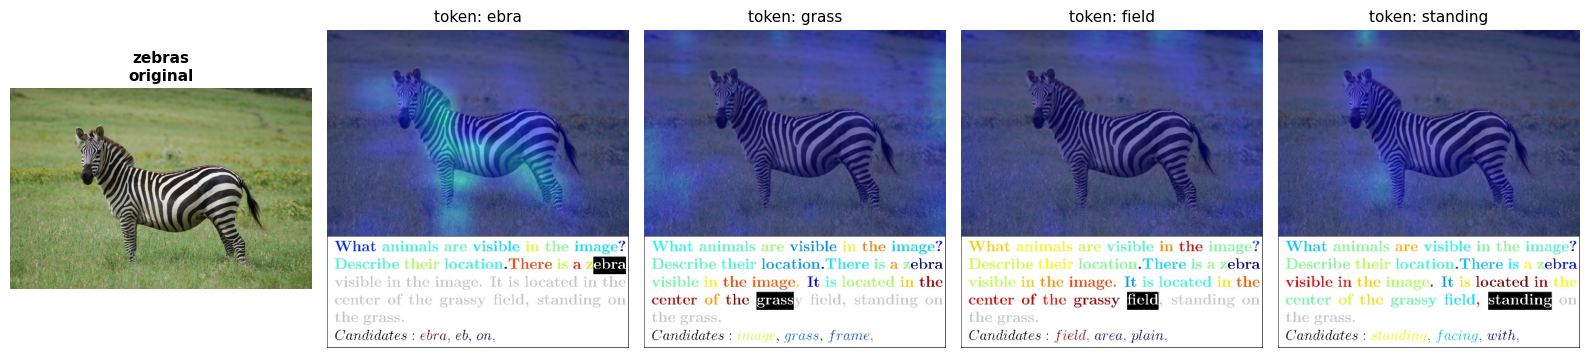

CASE: dog


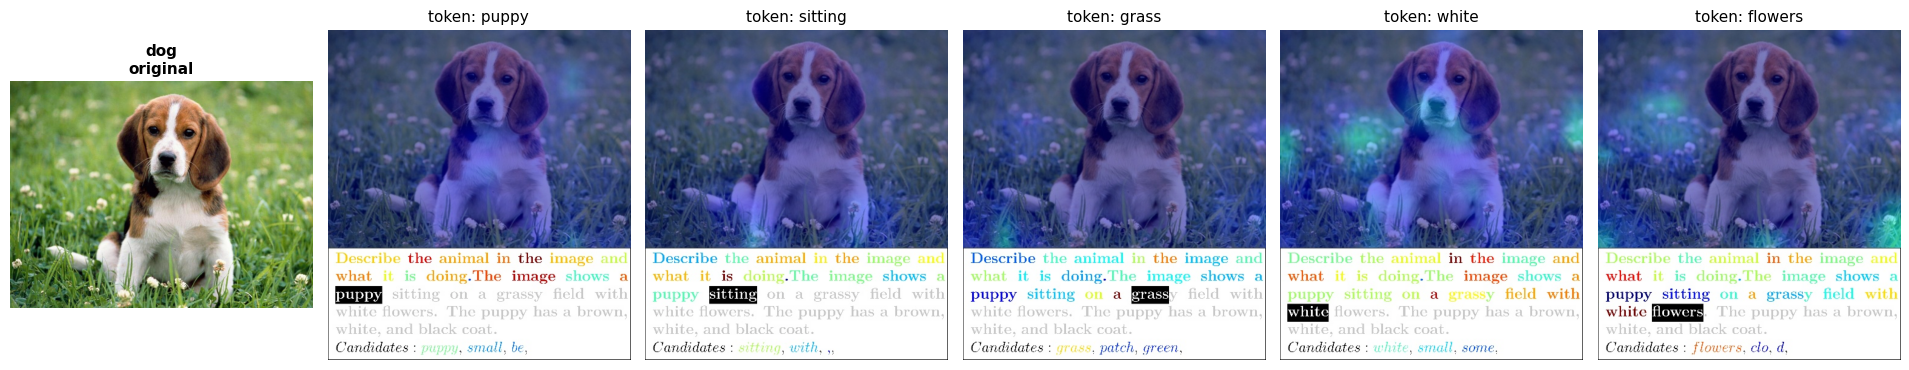

CASE: food


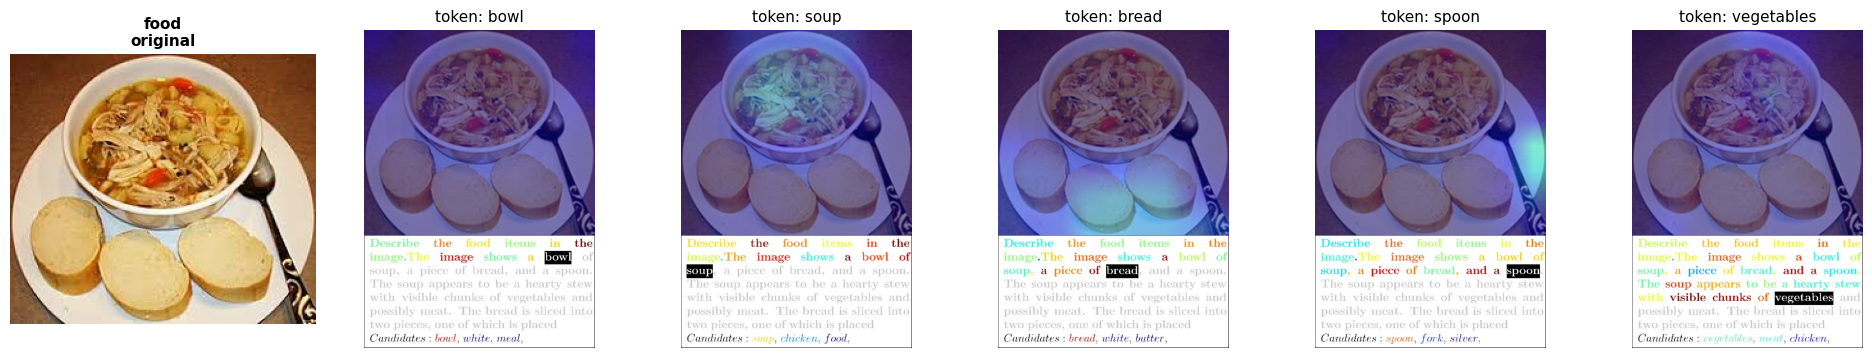

CASE: airplane


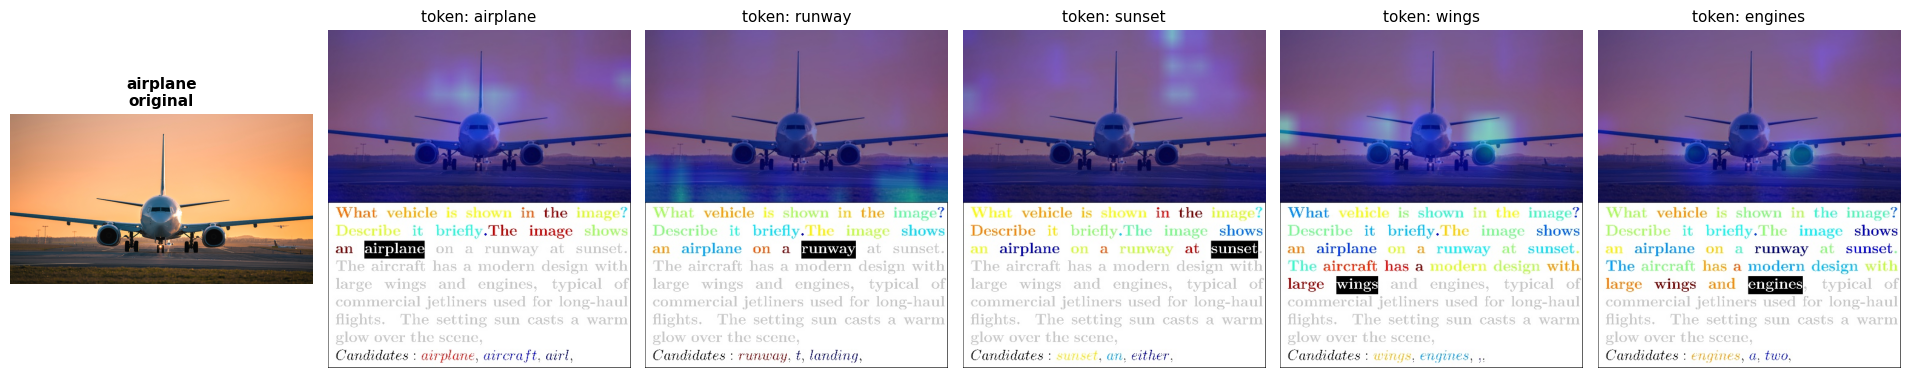

CASE: tennis


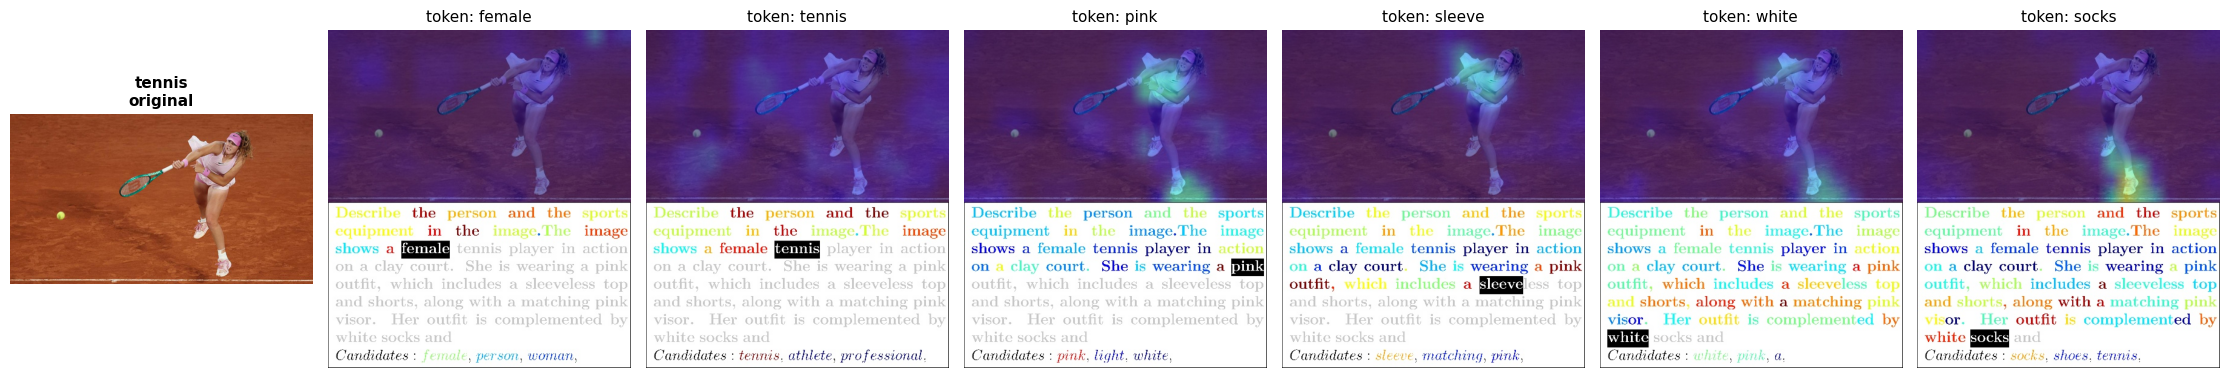

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image

manual_selection = {
    "zebras": {
        "original": "/content/tam_data_v2/images/Equus_quagga.jpg",
        "items": [
            ("/content/tam_outputs_v5/zebras/tam_token_004.jpg", "ebra"),
            ("/content/tam_outputs_v5/zebras/tam_token_018.jpg", "grass"),
            ("/content/tam_outputs_v5/zebras/tam_token_020.jpg", "field"),
            ("/content/tam_outputs_v5/zebras/tam_token_022.jpg", "standing"),
        ],
    },
    "dog": {
        "original": "/content/tam_data_v2/images/517676504.800x600w.jpg",
        "items": [
            ("/content/tam_outputs_v5/dog/tam_token_004.jpg", "puppy"),
            ("/content/tam_outputs_v5/dog/tam_token_005.jpg", "sitting"),
            ("/content/tam_outputs_v5/dog/tam_token_008.jpg", "grass"),
            ("/content/tam_outputs_v5/dog/tam_token_012.jpg", "white"),
            ("/content/tam_outputs_v5/dog/tam_token_013.jpg", "flowers"),
        ],
    },
    "food": {
        "original": "/content/tam_data_v2/images/images.jpeg",
        "items": [
            ("/content/tam_outputs_v5/food/tam_token_004.jpg", "bowl"),
            ("/content/tam_outputs_v5/food/tam_token_006.jpg", "soup"),
            ("/content/tam_outputs_v5/food/tam_token_011.jpg", "bread"),
            ("/content/tam_outputs_v5/food/tam_token_015.jpg", "spoon"),
            ("/content/tam_outputs_v5/food/tam_token_029.jpg", "vegetables"),
        ],
    },
    "airplane": {
        "original": "/content/tam_data_v2/images/66a78e3782682c6ff05a5ab4.jpg",
        "items": [
            ("/content/tam_outputs_v5/airplane/tam_token_004.jpg", "airplane"),
            ("/content/tam_outputs_v5/airplane/tam_token_007.jpg", "runway"),
            ("/content/tam_outputs_v5/airplane/tam_token_009.jpg", "sunset"),
            ("/content/tam_outputs_v5/airplane/tam_token_019.jpg", "wings"),
            ("/content/tam_outputs_v5/airplane/tam_token_021.jpg", "engines"),
        ],
    },
    "tennis": {
        "original": "/content/tam_data_v2/images/347803953499035.jpeg",
        "items": [
            ("/content/tam_outputs_v5/tennis/tam_token_004.jpg", "female"),
            ("/content/tam_outputs_v5/tennis/tam_token_005.jpg", "tennis"),
            ("/content/tam_outputs_v5/tennis/tam_token_018.jpg", "pink"),
            ("/content/tam_outputs_v5/tennis/tam_token_024.jpg", "sleeve"),
            ("/content/tam_outputs_v5/tennis/tam_token_044.jpg", "white"),
            ("/content/tam_outputs_v5/tennis/tam_token_045.jpg", "socks"),
        ],
    },
}


def show_manual_case(case_id, selection, figsize_per_img=3.2):
    """Рисует одну строку: оригинал + выбранные TAM-карты для класса."""
    entry = selection[case_id]
    original_path = entry["original"]
    items = entry["items"]

    n_imgs = 1 + len(items)

    fig, axes = plt.subplots(
        1, n_imgs,
        figsize=(figsize_per_img * n_imgs, figsize_per_img * 1.15)
    )
    if n_imgs == 1:
        axes = [axes]

    orig = Image.open(original_path).convert("RGB")
    axes[0].imshow(orig)
    axes[0].set_title(f"{case_id}\noriginal", fontsize=11, fontweight="bold")
    axes[0].axis("off")

    for ax, (tam_path, token) in zip(axes[1:], items):
        if not os.path.exists(tam_path):
            ax.text(0.5, 0.5, f"NOT FOUND\n{os.path.basename(tam_path)}",
                    ha="center", va="center", fontsize=9, color="red")
            ax.set_title(f"token: {token}", fontsize=10)
            ax.axis("off")
            continue

        tam_img = Image.open(tam_path).convert("RGB")
        ax.imshow(tam_img)
        ax.set_title(f"token: {token}", fontsize=11)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


def show_all_manual_cases(selection, figsize_per_img=3.2):
    """Рисует все классы единой сеткой: одна строка = один класс."""
    case_ids = list(selection.keys())
    n_rows = len(case_ids)
    n_cols = max(1 + len(selection[cid]["items"]) for cid in case_ids)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(figsize_per_img * n_cols, figsize_per_img * 1.15 * n_rows)
    )
    if n_rows == 1:
        axes = [axes]

    for row_idx, case_id in enumerate(case_ids):
        entry = selection[case_id]
        original_path = entry["original"]
        items = entry["items"]
        row_axes = axes[row_idx]


        orig = Image.open(original_path).convert("RGB")
        row_axes[0].imshow(orig)
        row_axes[0].set_title(f"{case_id}\noriginal",
                              fontsize=11, fontweight="bold")
        row_axes[0].axis("off")


        for col_idx, (tam_path, token) in enumerate(items, start=1):
            ax = row_axes[col_idx]
            if not os.path.exists(tam_path):
                ax.text(0.5, 0.5, f"NOT FOUND\n{os.path.basename(tam_path)}",
                        ha="center", va="center", fontsize=9, color="red")
                ax.set_title(f"token: {token}", fontsize=10)
                ax.axis("off")
                continue

            tam_img = Image.open(tam_path).convert("RGB")
            ax.imshow(tam_img)
            ax.set_title(f"token: {token}", fontsize=11)
            ax.axis("off")


        for col_idx in range(1 + len(items), n_cols):
            row_axes[col_idx].axis("off")

    plt.tight_layout()
    plt.show()


for case_id in manual_selection.keys():
    print("=" * 80)
    print(f"CASE: {case_id}")
    show_manual_case(case_id, manual_selection, figsize_per_img=3.2)



По полученным визуализациям можно сказать, что TAM в целом хорошо объясняет значимые токены, хоть иногда делает это не очень уверенно. К сожалению картинки я уже вставить не смогу (среда слетела), но было замечено, что метод очень активно реагирует на "мусорные" токены по типу "on", "the" и выделяет на картинке конкретные области, которые их описывают, что довольно странно.